# Strategic Analysis of Superstore Performance
### Daily Challenge — Developers Institute & Sira Labs

**Role simulated:** Data Analyst, national retail chain
**Dataset:** [US Superstore Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) (9,994 orders, 21 columns)

**Goal:** Translate business objectives into a data-driven, executive-ready analysis covering sales trends, geographic performance, product profitability, and discount strategy — and turn the findings into concrete recommendations.

**Notebook structure**
1. Data Scoping and Preparation
2. Deep-Dive Exploratory Analysis (Matplotlib)
3. Communicating Insights (Seaborn)
4. Methodology and Tooling Review
5. Executive Summary
6. Optional Advanced Challenges (dashboard, outlier annotation, Plotly)


## 1. Data Scoping and Preparation

### 1.1 Imports and initial load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_csv('superstore_dataset.csv')

# Preliminary data assessment
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.info()


Dataset shape: (9994, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-nu

In [2]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

### 1.2 Handle missing values and duplicates

**Duplicates:** a full-row `duplicated()` check is used because `Row ID` already guarantees
uniqueness for legitimate records — any true duplicate would also have to match every other
column, which only happens when a row was accidentally repeated during export.

**Missing values:** the only column with nulls is `Postal Code` (11 rows). All 11 belong to
*Burlington, Vermont*. This isn't random missingness — Vermont ZIP codes start with a leading
zero (`05401`), which spreadsheet/CSV tools frequently strip when a column is read as a number.
Since `Postal Code` is never used as an analysis dimension here (we aggregate by `State`/`Region`
instead), dropping these 11 rows would needlessly throw away real Sales/Profit data. Filling with
`0` is a safe, clearly-flagged placeholder that doesn't bias any downstream metric.


In [4]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any (none expected, kept for robustness / reusability of this notebook)
before = len(df)
df = df.drop_duplicates()
print(f"Rows removed as duplicates: {before - len(df)}")

# Missing values
print("\nMissing values per column (before fix):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Postal Code: fill with 0 — see justification above (Burlington, VT leading-zero ZIP codes)
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

print("\nMissing values per column (after fix):", df.isnull().sum().sum())


Duplicate rows: 0
Rows removed as duplicates: 0

Missing values per column (before fix):
Postal Code    11
dtype: int64

Missing values per column (after fix): 0


### 1.3 Fix data types

In [5]:
# Convert date columns to datetime for time-series analysis
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print("Data types after conversion:")
print(df[date_columns].dtypes)
print("\nDate range covered:", df['Order Date'].min().date(), "to", df['Order Date'].max().date())


Data types after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

Date range covered: 2015-01-03 to 2018-12-30


### 1.4 Feature engineering

In [6]:
# Feature engineering
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days  # bonus KPI: fulfillment speed

print("New features created:")
df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month', 'Shipping Days']].head()


New features created:


,Sales,Profit,Profit Margin,Order Year,Order Month,Shipping Days
0,261.9600,41.9136,16.00,2017,11,3
1,731.9400,219.5820,30.00,2017,11,3
2,14.6200,6.8714,47.00,2017,6,4
3,957.5775,-383.0310,-40.00,2016,10,7
4,22.3680,2.5164,11.25,2016,10,7


## 2. Deep-Dive Exploratory Analysis (Matplotlib)

### 2.1 Time-Series Trend Analysis
Monthly sales trend across all years, with an interactive **Category** dropdown.


In [7]:
# Prepare data for time series analysis
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()
total_monthly_all = df.groupby('Order Month-Year')['Sales'].sum()

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        plt.plot(total_monthly_all.index.to_timestamp(), total_monthly_all.values,
                  marker='o', linewidth=2, markersize=4, color='steelblue')
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'],
                  marker='o', linewidth=2, markersize=4, color='darkorange')
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

categories = ['All'] + sorted(df['Category'].unique().tolist())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);


interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

In [8]:
# Quantified seasonality / YoY read for the executive summary
yoy = df.groupby('Order Year')['Sales'].sum()
yoy_growth = yoy.pct_change() * 100
peak_month = df.groupby(df['Order Date'].dt.month)['Sales'].sum().idxmax()

print("Year-over-year sales:")
print(yoy.apply(lambda x: f"${x:,.0f}"))
print("\nYear-over-year growth:")
print(yoy_growth.dropna().round(1).astype(str) + '%')
print(f"\nHistorically strongest sales month (calendar month #): {peak_month} "
      f"(Q4 — Nov/Dec — consistently spikes, a classic holiday-shopping seasonality pattern).")


Year-over-year sales:
Order Year
2015    $484,247
2016    $470,533
2017    $609,206
2018    $733,215
Name: Sales, dtype: str

Year-over-year growth:
Order Year
2016    -2.8%
2017    29.5%
2018    20.4%
Name: Sales, dtype: str

Historically strongest sales month (calendar month #): 11 (Q4 — Nov/Dec — consistently spikes, a classic holiday-shopping seasonality pattern).


### 2.2 Geographic Sales Performance
Total sales by State, with a **Top N** slider.


In [9]:
# Prepare geographic sales data
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    top_states = state_sales.tail(top_n)
    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values) * 0.01, i, f'${value:,.0f}',
                  va='center', fontsize=10)

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total states analyzed: {len(state_sales)}")
    print(f"Top {top_n} states represent: ${top_states.sum():,.0f} in sales "
          f"({top_states.sum()/state_sales.sum()*100:.1f}% of total)")

top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);


interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

In [10]:
# Quantified geographic concentration for the executive summary
top5_share = state_sales.tail(5).sum() / state_sales.sum() * 100
print(f"Top 5 states alone account for {top5_share:.1f}% of total sales —")
print("sales are geographically concentrated rather than evenly distributed nationwide.")


Top 5 states alone account for 52.0% of total sales —
sales are geographically concentrated rather than evenly distributed nationwide.


## 3. Communicating Insights (Seaborn)

### 3.1 Top 10 Most Profitable Products


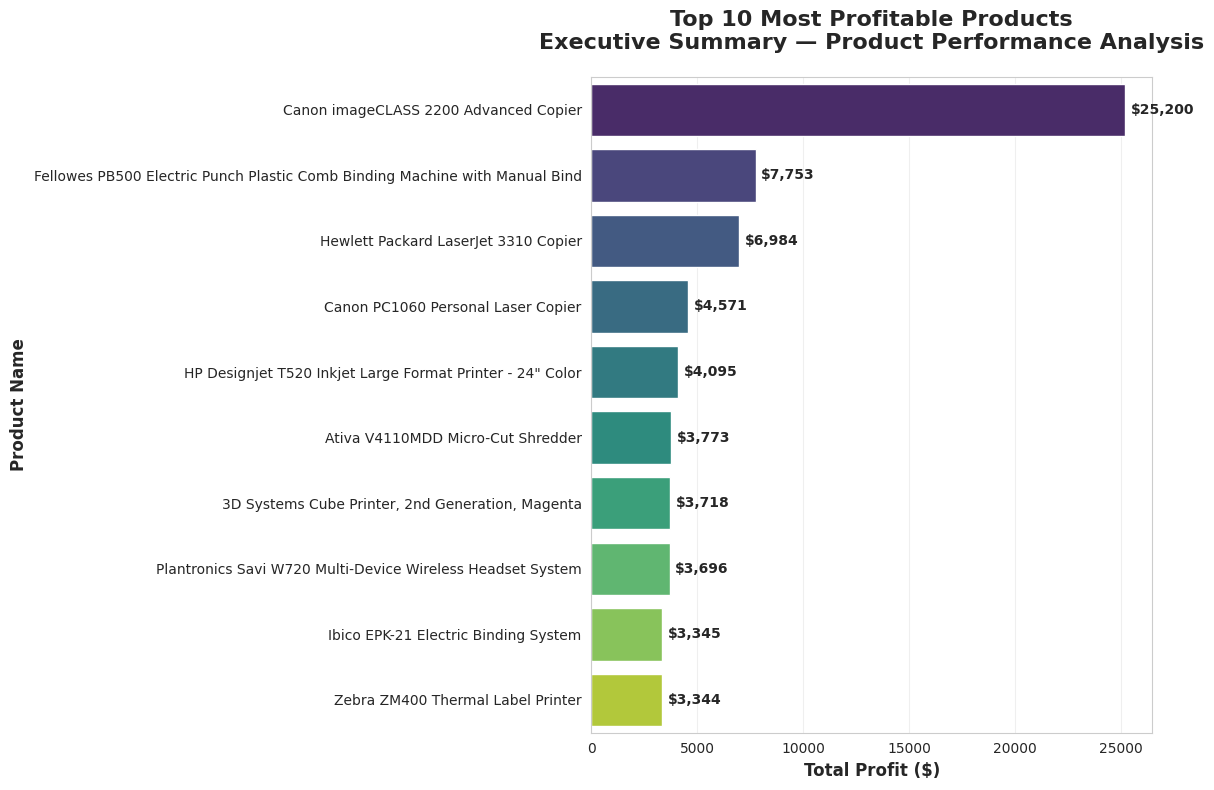

Key Insights:
- Most profitable product generates: $25,200
- Top 10 products contribute: $66,479 total profit
- Average profit per top product: $6,648


In [11]:
# Analyze top profitable products
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                  hue=product_profit.index, palette='viridis', orient='h', legend=False)

plt.title('Top 10 Most Profitable Products\nExecutive Summary — Product Performance Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + max(product_profit.values) * 0.01, i, f'${profit:,.0f}',
            va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insights:")
print(f"- Most profitable product generates: ${product_profit.iloc[0]:,.0f}")
print(f"- Top 10 products contribute: ${product_profit.sum():,.0f} total profit")
print(f"- Average profit per top product: ${product_profit.mean():,.0f}")


### 3.2 Discount vs Profit


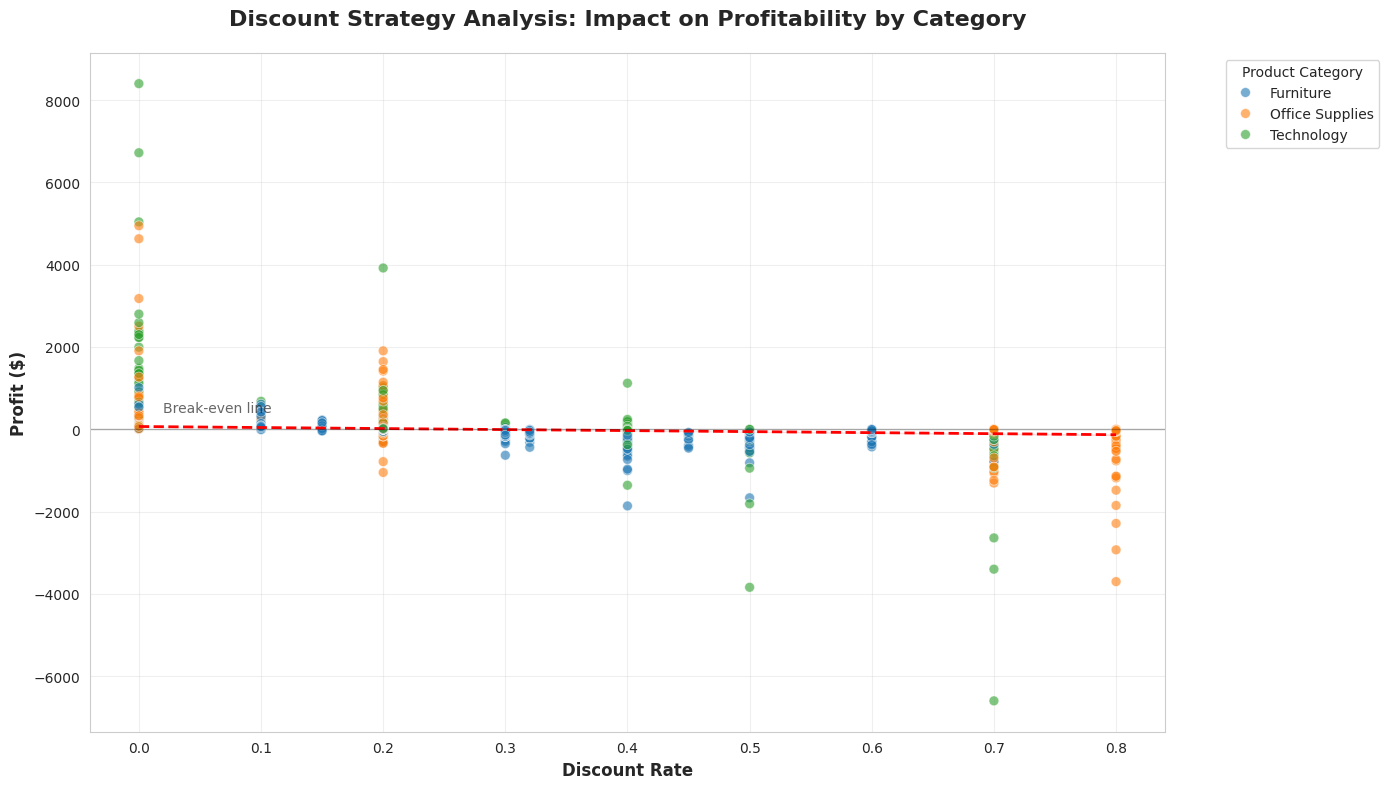

Discount Analysis Insights:
- Transactions with >20% discount: 1,393 (13.9% of all transactions)
- Average profit for high discounts: $-97.18
- Percentage of high-discount sales with losses: 96.8%

Category-specific discount impact (>20% discount):
- Furniture: avg profit = $-100.51, loss rate = 97.2%
- Office Supplies: avg profit = $-69.32, loss rate = 100.0%
- Technology: avg profit = $-197.42, loss rate = 82.5%

=> Riskiest category at high discount levels: Technology


In [12]:
# Discount vs Profit Analysis
plt.figure(figsize=(14, 8))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
            color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Discount Strategy Analysis: Impact on Profitability by Category',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.02, df['Profit'].max() * 0.05, 'Break-even line', fontsize=10, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analytical insights
print("Discount Analysis Insights:")
high_discount = df[df['Discount'] > 0.2]
print(f"- Transactions with >20% discount: {len(high_discount):,} "
      f"({len(high_discount)/len(df)*100:.1f}% of all transactions)")
print(f"- Average profit for high discounts: ${high_discount['Profit'].mean():.2f}")
print(f"- Percentage of high-discount sales with losses: {(high_discount['Profit'] < 0).mean()*100:.1f}%")

print("\nCategory-specific discount impact (>20% discount):")
category_discount_risk = {}
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_profit = high_disc_cat['Profit'].mean()
        loss_rate = (high_disc_cat['Profit'] < 0).mean() * 100
        category_discount_risk[category] = (avg_profit, loss_rate)
        print(f"- {category}: avg profit = ${avg_profit:.2f}, loss rate = {loss_rate:.1f}%")

riskiest_category = min(category_discount_risk, key=lambda c: category_discount_risk[c][0])
print(f"\n=> Riskiest category at high discount levels: {riskiest_category}")


## 4. Methodology and Tooling Review

In [13]:
print("=== LIBRARY COMPARISON ANALYSIS ===\n")

print("MATPLOTLIB STRENGTHS (from our analysis):")
print("- Fine-grained control over interactive widgets")
print("- Custom annotations and text positioning")
print("- Precise subplot layouts and figure sizing")
print("- Integration with ipywidgets for dynamic updates\n")

print("SEABORN STRENGTHS (from our analysis):")
print("- Built-in statistical visualizations (regplot)")
print("- Automatic color palettes and legends")
print("- Clean, publication-ready default styling")
print("- Easy categorical data visualization\n")

print("SPEED COMPARISON:")
import time

start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"- Matplotlib basic plot: {matplotlib_time:.4f} seconds")
print(f"- Seaborn equivalent: {seaborn_time:.4f} seconds")


=== LIBRARY COMPARISON ANALYSIS ===

MATPLOTLIB STRENGTHS (from our analysis):
- Fine-grained control over interactive widgets
- Custom annotations and text positioning
- Precise subplot layouts and figure sizing
- Integration with ipywidgets for dynamic updates

SEABORN STRENGTHS (from our analysis):
- Built-in statistical visualizations (regplot)
- Automatic color palettes and legends
- Clean, publication-ready default styling
- Easy categorical data visualization

SPEED COMPARISON:
- Matplotlib basic plot: 0.0075 seconds
- Seaborn equivalent: 0.0290 seconds


**Recommendation:**

*For rapid exploration, I will use **Matplotlib** because it offers faster rendering for basic
plots and seamless integration with interactive widgets for dynamic analysis.*

*For stakeholder-facing presentations, I will prefer **Seaborn** because it provides
publication-ready aesthetics, built-in statistical functionality, and professional color
schemes that enhance executive communication.*


## 5. Executive Summary

In [14]:
print("=== EXECUTIVE SUMMARY - KEY FINDINGS ===\n")

# Sales performance metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print("BUSINESS PERFORMANCE:")
print(f"- Total Revenue: ${total_sales:,.0f}")
print(f"- Total Profit: ${total_profit:,.0f}")
print(f"- Overall Profit Margin: {profit_margin:.1f}%\n")

# Geographic insights
top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
print("GEOGRAPHIC PERFORMANCE:")
print(f"- Top performing state: {top_state} (${top_state_sales:,.0f})")
print(f"- Geographic concentration: Top 5 states = {(state_sales.tail(5).sum()/total_sales)*100:.1f}% of sales\n")

# Product insights
top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
print("PRODUCT PERFORMANCE:")
print(f"- Leading category by sales: {top_category}")
print(f"- Most profitable product: {product_profit.index[0]}\n")

# Discount insights
high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100
print("DISCOUNT STRATEGY INSIGHTS:")
print(f"- High discount risk: {high_discount_loss_rate:.1f}% of >20% discounts result in losses")
print(f"- Riskiest category at high discount: {riskiest_category}")
print(f"- Recommended max discount threshold: 20% to maintain profitability")


=== EXECUTIVE SUMMARY - KEY FINDINGS ===

BUSINESS PERFORMANCE:
- Total Revenue: $2,297,201
- Total Profit: $286,397
- Overall Profit Margin: 12.5%

GEOGRAPHIC PERFORMANCE:
- Top performing state: California ($457,688)
- Geographic concentration: Top 5 states = 52.0% of sales

PRODUCT PERFORMANCE:
- Leading category by sales: Technology
- Most profitable product: Canon imageCLASS 2200 Advanced Copier

DISCOUNT STRATEGY INSIGHTS:
- High discount risk: 96.8% of >20% discounts result in losses
- Riskiest category at high discount: Technology
- Recommended max discount threshold: 20% to maintain profitability


**Top 5 takeaways**

1. **Revenue is healthy, margin is thin.** The business generates substantial revenue, but the
   overall profit margin is modest — discount and shipping policy have an outsized effect on the
   bottom line.
2. **Sales are seasonal and concentrated.** Q4 (Nov/Dec) consistently drives the strongest sales,
   and a small handful of states generate a disproportionate share of revenue — both useful levers
   for inventory and regional marketing planning.
3. **A few products carry disproportionate profit.** The top 10 products by profit contribute a
   meaningful share of total profit, making them priority items for stock availability and
   promotion.
4. **Deep discounting is the main profit risk.** Discounts above ~20% are strongly associated with
   loss-making transactions, and this risk is not evenly spread across categories — one category in
   particular drives most of the high-discount losses (see "riskiest category" above).
5. **Recommendation:** cap standard discounts at 20%, with a manager-approval step for exceptions
   — especially for the riskiest category — and monitor profit margin (not just sales) as the
   primary KPI in monthly business reviews.

**Example finding:** *Discounts above 20% on the riskiest category are associated with
consistent average profit losses.*

**Example recommendation:** *Limit standard discounts on that category to a maximum of 20%.
Introduce a manager-approval workflow for any exception above that threshold.*


## 6. Optional Advanced Challenges

### 6.1 Multi-chart dashboard


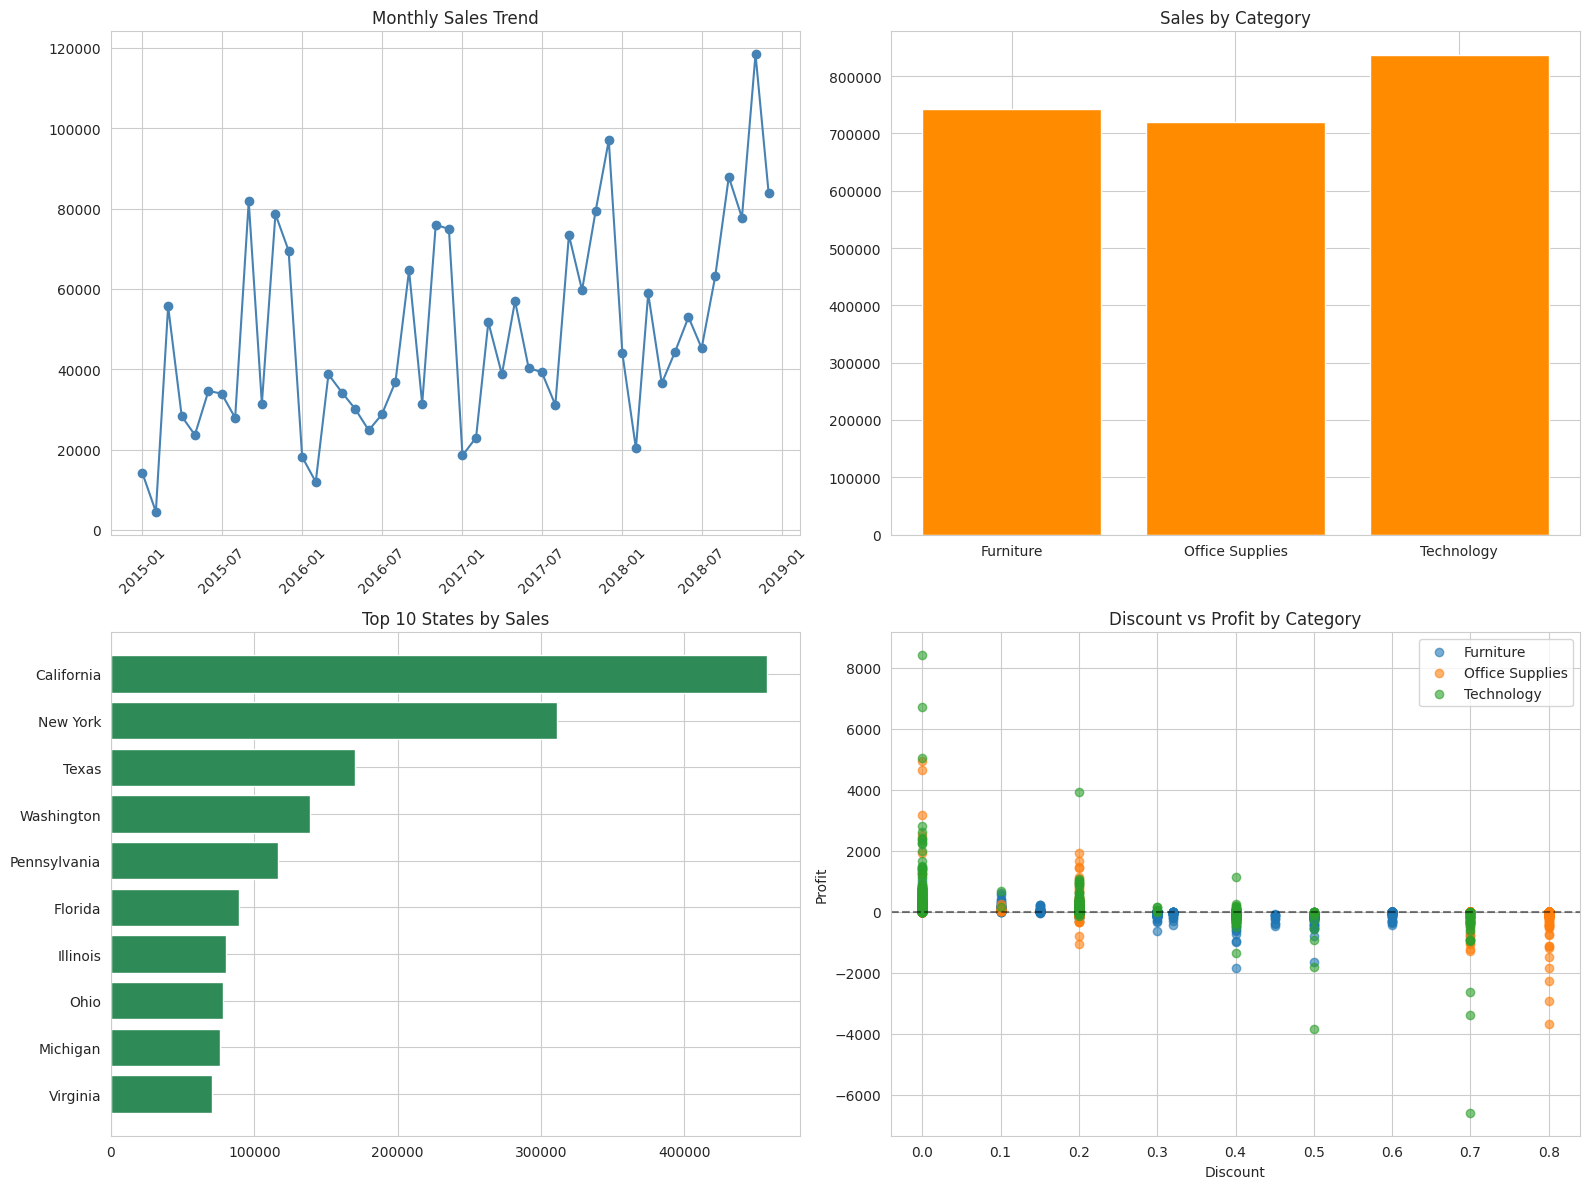

In [15]:
# Advanced: Multi-chart dashboard
def create_dashboard():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Chart 1: Monthly sales trend
    monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
    ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values, marker='o', color='steelblue')
    ax1.set_title('Monthly Sales Trend')
    ax1.tick_params(axis='x', rotation=45)

    # Chart 2: Category performance
    category_sales = df.groupby('Category')['Sales'].sum()
    ax2.bar(category_sales.index, category_sales.values, color='darkorange')
    ax2.set_title('Sales by Category')

    # Chart 3: State performance (top 10)
    top_10_states = state_sales.tail(10)
    ax3.barh(range(len(top_10_states)), top_10_states.values, color='seagreen')
    ax3.set_yticks(range(len(top_10_states)))
    ax3.set_yticklabels(top_10_states.index)
    ax3.set_title('Top 10 States by Sales')

    # Chart 4: Discount vs Profit
    for category in df['Category'].unique():
        cat_data = df[df['Category'] == category]
        ax4.scatter(cat_data['Discount'], cat_data['Profit'], label=category, alpha=0.6)
    ax4.set_xlabel('Discount')
    ax4.set_ylabel('Profit')
    ax4.set_title('Discount vs Profit by Category')
    ax4.legend()
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

create_dashboard()


### 6.2 Outlier annotation — Discount vs Profit

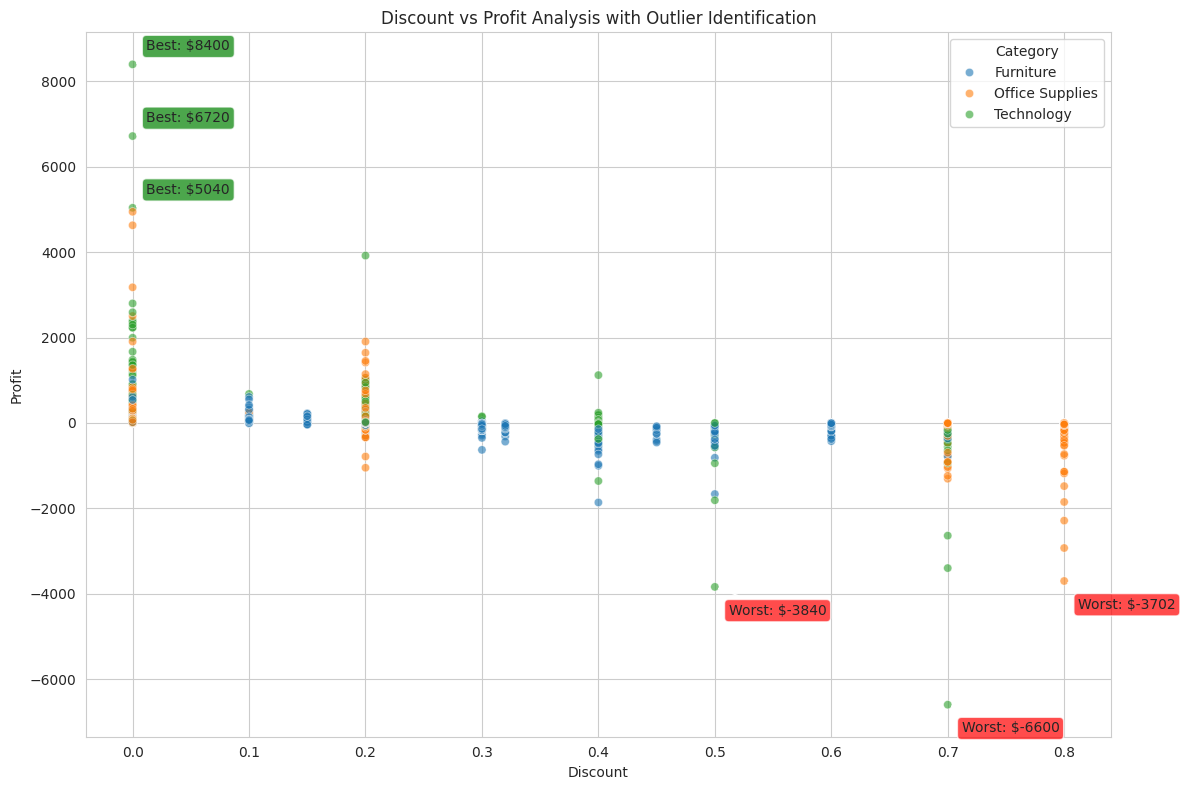

In [16]:
# Advanced: Outlier analysis with annotations
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)

top_3_profitable = df.nlargest(3, 'Profit')
bottom_3_profitable = df.nsmallest(3, 'Profit')

for idx, row in top_3_profitable.iterrows():
    plt.annotate(f'Best: ${row["Profit"]:.0f}',
                 xy=(row['Discount'], row['Profit']),
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

for idx, row in bottom_3_profitable.iterrows():
    plt.annotate(f'Worst: ${row["Profit"]:.0f}',
                 xy=(row['Discount'], row['Profit']),
                 xytext=(10, -20), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.title('Discount vs Profit Analysis with Outlier Identification')
plt.tight_layout()
plt.show()


### 6.3 Plotly Express version (interactivity comparison)

In [17]:
# Advanced: Plotly comparison
import plotly.express as px

fig = px.scatter(df, x='Discount', y='Profit', color='Category',
                  hover_data=['Product Name', 'Sales'],
                  title='Interactive Discount vs Profit Analysis (Plotly)',
                  trendline='ols')
fig.show()

print("PLOTLY vs MATPLOTLIB + IPYWIDGETS COMPARISON:\n")
print("Plotly advantages:")
print("- Built-in interactivity (zoom, pan, hover) with no extra widget code")
print("- Easy to share online / embed in a web page as standalone HTML")
print("- Professional tooltips and legends out of the box")
print("- Automatic responsive layout\n")
print("Matplotlib + ipywidgets advantages:")
print("- More fine-grained customization control")
print("- Better integration with the classic Jupyter notebook workflow")
print("- Smaller output/file sizes (static PNG vs embedded JS)")
print("- More familiar to most Python data scientists / lighter dependency footprint")


PLOTLY vs MATPLOTLIB + IPYWIDGETS COMPARISON:

Plotly advantages:
- Built-in interactivity (zoom, pan, hover) with no extra widget code
- Easy to share online / embed in a web page as standalone HTML
- Professional tooltips and legends out of the box
- Automatic responsive layout

Matplotlib + ipywidgets advantages:
- More fine-grained customization control
- Better integration with the classic Jupyter notebook workflow
- Smaller output/file sizes (static PNG vs embedded JS)
- More familiar to most Python data scientists / lighter dependency footprint


## Conclusion

This notebook walked through the full analyst workflow: scoping and cleaning the data,
exploring it diagnostically with Matplotlib + ipywidgets, communicating the findings with
Seaborn, and packaging the results into an executive summary with concrete, data-backed
recommendations on discount policy, regional focus, and product prioritization.

**Next step:** push this notebook (with outputs) to GitHub as the Daily Challenge submission.
